# *Predicting Loan Approval Using Logistic Regression and Decision Tree with GridSearch Optimization* 

# Data Preparation and Preprocessing

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, KFold

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [25]:
df = pd.read_csv('/kaggle/input/datasets/architsharma01/loan-approval-prediction-dataset/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [27]:
df['loan_id'].duplicated().sum()

np.int64(0)

In [28]:
df = df.drop('loan_id', axis=1)

In [29]:
num_f = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value',
         'luxury_assets_value', 'bank_asset_value']
cat_f = ['no_of_dependents','education', 'self_employed', 'loan_status']

In [30]:
df.isna().sum().sum()

np.int64(0)

In [31]:
columns = df.columns

In [32]:
df.columns = columns.str.lower().str.strip()

In [33]:
# columns need encoding
#  2    education                 4269 non-null   object
#  3    self_employed             4269 non-null   object
#  12   loan_status               4269 non-null   object
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [34]:
df['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [35]:
print(df['education'].unique()) # look at the output, we have some spaces that need to be stripped

[' Graduate' ' Not Graduate']


In [36]:
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df['loan_status'] = df['loan_status'].str.strip()

df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})
df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

df[['education','self_employed','loan_status']] = df[['education','self_employed','loan_status']].astype(int)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(12)
memory usage: 400.3 KB


In [38]:
scaler = StandardScaler()
df[num_f]=scaler.fit_transform(df[num_f])

In [39]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,1.617979,1.633052,0.192617,1.032792,-0.780058,2.877289,0.832028,0.930304,1
1,0,0,1,-0.341750,-0.324414,-0.508091,-1.061051,-0.733924,-0.631921,-0.694993,-0.515936,0
2,3,1,0,1.439822,1.610933,1.594031,-0.544840,-0.057300,-0.107818,1.996520,2.407316,0
3,3,1,0,1.119139,1.721525,-0.508091,-0.771045,1.649637,-0.381263,0.897943,0.899533,0
4,5,0,1,1.689242,1.002681,1.594031,-1.264055,0.757724,0.735304,1.568075,0.007172,0


# Train Test Split and Utility Functions

In [40]:
x = df.drop('loan_status', axis=1)
y = df['loan_status']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=7, stratify=y)

In [41]:
def eval(y_test, y_pred):
  acc = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1_val = f1_score(y_test, y_pred)
  f1_macro = f1_score(y_test, y_pred, average='macro')
  cm = confusion_matrix(y_test, y_pred)

  metrics = {'accuracy_score':acc,
             'precision_score':precision,
             'recall_score':recall,
             'f1_score':f1_val,
             'f1_macro':f1_macro}
  print(classification_report(y_test, y_pred))

  return metrics, cm

In [42]:
def grid_search(model, param_grid):
    
    kf = KFold(n_splits=5, shuffle=True, random_state=7)

    grid_search = GridSearchCV(model, param_grid=param_grid, cv=kf, scoring='f1')
    grid_search.fit(x_train, y_train)
 
    print(f'Best Parameters: {grid_search.best_params_}')
    print(f'Best F1 Score: {grid_search.best_score_}')
    print(f'Feature Importances: {getattr(grid_search.best_estimator_, "feature_importances_", "N/A")}')
    return grid_search.best_estimator_

In [43]:
def plot_confusion_matrix(model, cm):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.show()

# Logistic Regression Model

## Baseline Model Without Regularization

In [44]:
log_reg = LogisticRegression(penalty='l2', C=1, solver='lbfgs', max_iter=1000, random_state=7) # random params
log_reg.fit(x_train, y_train)

y_pred = log_reg.predict(x_test)
metrics, cm = eval(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       484
           1       0.94      0.93      0.93       797

    accuracy                           0.92      1281
   macro avg       0.91      0.92      0.91      1281
weighted avg       0.92      0.92      0.92      1281



## Optimizing Model Parameters Using GridSearchCV

Best Parameters: {'C': 0.1, 'l1_ratio': 0, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 Score: 0.9375824108374212
Feature Importances: N/A
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       484
           1       0.94      0.93      0.93       797

    accuracy                           0.92      1281
   macro avg       0.91      0.92      0.91      1281
weighted avg       0.92      0.92      0.92      1281



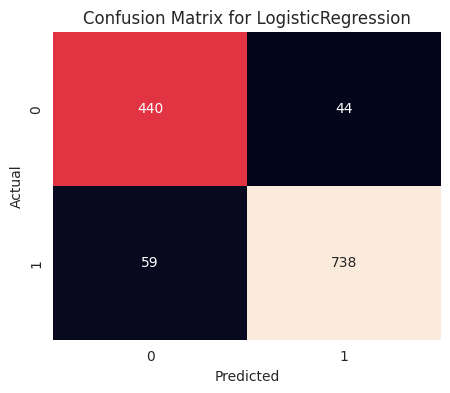

In [45]:
log_param_grid = {
    'C':[0.001, 0.01, 0.1, 1, 10, 100],
    'penalty':['l1', 'l2'],
    'solver':['lbfgs', 'liblinear'],
    'l1_ratio':[0, 0.5, 1]
}

best_log = grid_search(log_reg, log_param_grid)
y_pred = best_log.predict(x_test)

metrics, cm = eval(y_test, y_pred)
plot_confusion_matrix(best_log, cm)

# Decision Tree Model

## Baseline Model

In [ ]:
DT = DecisionTreeClassifier(criterion='gini', random_state=7) # same as logistic for some test we put random params
DT.fit(x_train, y_train)

y_pred = DT.predict(x_test)
metrics, cm = eval(y_test, y_pred)

## Hyperparameter Tuning with GridSearchCV

In [ ]:
grid_params = {'criterion':['gini', 'entropy'],
               'max_depth':[3, 4, 5, 6, 7, 8, 9, 10],
               'min_samples_split':[2,3,4,6,8,10],
               'min_samples_leaf':[1,2,3,4,5],
               'max_leaf_nodes':[None, 10, 20, 30, 40, 50]}

best_DT = grid_search(DT, grid_params)
y_pred = best_DT.predict(x_test)

metrics, cm = eval(y_test, y_pred)
plot_confusion_matrix(best_log, cm)

### Visualizing the Best Decision Tree

In [ ]:
plt.figure(figsize=(12,8), dpi=1200, edgecolor='k')
plot_tree(best_DT, filled=True, fontsize=5)
plt.show()

# Model Comparison and Analysis

This project included four main experiments:

1. Logistic Regression without hyperparameter tuning  
2. Logistic Regression with GridSearchCV and regularization tuning  
3. Decision Tree without tuning  
4. Decision Tree with GridSearchCV tuning  

Total number of experiments conducted: **4**

---

## Logistic Regression  

### Before Tuning  

Test Results:

- Accuracy: **0.92**  

| Class | Precision | Recall | F1-score | Support |
|--------|-----------|--------|----------|----------|
| 0 | 0.88 | 0.90 | 0.89 | 484 |
| 1 | 0.94 | 0.93 | 0.93 | 797 |

Macro Avg F1-score: **0.91**  
Weighted Avg F1-score: **0.92**

The model performed well and showed balanced precision and recall across both classes.

---

### After GridSearchCV  

Best Parameters:  
`C = 0.1`  
`penalty = l1`  
`solver = liblinear`  

Best Cross-Validated F1 Score: **0.9376**

Test Results:

- Accuracy: **0.92**

| Class | Precision | Recall | F1-score | Support |
|--------|-----------|--------|----------|----------|
| 0 | 0.88 | 0.91 | 0.90 | 484 |
| 1 | 0.94 | 0.93 | 0.93 | 797 |

Macro Avg F1-score: **0.91**  
Weighted Avg F1-score: **0.92**

Regularization slightly improved class balance but overall accuracy remained stable. The model maintained strong generalization.

---

## Decision Tree  

### Before Tuning  

Test Results:

- Accuracy: **0.97**

| Class | Precision | Recall | F1-score | Support |
|--------|-----------|--------|----------|----------|
| 0 | 0.96 | 0.97 | 0.96 | 484 |
| 1 | 0.98 | 0.97 | 0.98 | 797 |

Macro Avg F1-score: **0.97**  
Weighted Avg F1-score: **0.97**

The untuned Decision Tree achieved significantly higher performance than Logistic Regression.

---

### After GridSearchCV  

Best Parameters:  
`criterion = entropy`  
`max_depth = 10`  
`max_leaf_nodes = 20`  
`min_samples_leaf = 2`  
`min_samples_split = 2`

Best Cross-Validated F1 Score: **0.9852**

Feature Importances:
[0.0000, 0.0000, 0.0000, 0.0222, 0.0303, 0.1233,
0.8016, 0.0176, 0.0049, 0.0000, 0.0000]


Test Results:

- Accuracy: **0.97**

| Class | Precision | Recall | F1-score | Support |
|--------|-----------|--------|----------|----------|
| 0 | 0.97 | 0.95 | 0.96 | 484 |
| 1 | 0.97 | 0.98 | 0.98 | 797 |

Macro Avg F1-score: **0.97**  
Weighted Avg F1-score: **0.97**

Hyperparameter tuning stabilized the tree and maintained strong performance while controlling complexity.

---

# Final Model Selection and Conclusion   

| Model | Tuning | Test Accuracy |
|--------|--------|---------------|
| Logistic Regression | No | 0.92 |
| Logistic Regression | Yes | 0.92 |
| Decision Tree | No | 0.97 |
| Decision Tree | Yes | 0.97 |

### Best Model  

The **Decision Tree after tuning** achieved the highest overall performance and strongest F1 score.  

Although Logistic Regression is more interpretable and simpler, the Decision Tree demonstrated superior predictive power on this dataset.

The final selected model is the **tuned Decision Tree**, as it provides the best balance between accuracy, class performance, and optimized hyperparameters.